# TEOS Thermodynamic Characterization for RPA
### Project: Asteria

This notebook calculates the **NASA 9-polynomial** coefficients for Tetraethyl orthosilicate (TEOS), enabling accurate simulations in **RPA (Rocket Propulsion Analysis)**.

We define two critical temperature ranges:
1. **Liquid Range (200K - 441.2K):** Essential for regenerative cooling channel modeling and fuel transport.
2. **Gaseous Range (441.2K - 5000K):** Necessary for combustion solver stability and film cooling boundary layer calculations.

### Methodology: From NIST Tables to NASA Polynomials
To ensure the highest fidelity for the **ARIS project**, we avoided generic approximations. Instead:
* **Data Sourcing:** We extracted experimental $C_p$ data from NIST-validated thermodynamic tables (Anand et al.).
* **Regression:** We performed a non-linear least squares fit using `scipy.optimize.curve_fit` to map experimental points to the NASA 9-term functional form.
* **Consistency:** Enthalpy ($b_1$) and Entropy ($b_2$) integration constants were solved using the liquid-phase standard state at 298.15K and accounting for the **Heat of Vaporization ($\Delta H_{vap}$)** at the boiling point to ensure a seamless transition between phases.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Universal Gas Constant
R = 8.314462618  # J/mol*K

# TEOS Properties (Tetraethyl orthosilicate - SiC8H20O4)
# Derived from NIST and Burcat correlations for IgnisFlow
hf_298_liq = -1408000.0  # Liquid Enthalpy of Formation [J/mol]
s0_298_liq = 533.1       # Standard Entropy [J/mol*K]
h_vap = 50000            # Estimated Latent Heat of Vaporization [J/mol]
t_boil = 441.2           # Boiling Point [K]

print(f"Base properties loaded for TEOS.")
print(f"Boiling Point: {t_boil} K")

Base properties loaded for TEOS.
Boiling Point: 441.2 K


## NASA 9-Polynomial Coefficient Calculation
In this section, we fit the Specific Heat ($C_p$) function to obtain coefficients $a_1$ through $a_7$, and then integrate to find $b_1$ (enthalpy) and $b_2$ (entropy).

The NASA 9-polynomial structure is:
$$\frac{C_p}{R} = a_1 T^{-2} + a_2 T^{-1} + a_3 + a_4 T + a_5 T^2 + a_6 T^3 + a_7 T^4$$

In [23]:
def get_nasa9_coeffs_final(phase="liquid"):
    # NASA 9-polynomial form for Cp/R
    def nasa_cp_form(T, a1, a2, a3, a4, a5, a6, a7):
        return a1*T**-2 + a2*T**-1 + a3 + a4*T + a5*T**2 + a6*T**3 + a7*T**4

    if phase == "liquid":
        # --- EXPERIMENTAL DATA: TABLE 1 (LIQUID) ---
        # Temperatures (K) and non-dimensional Cp/R from NIST Table
        T_data = np.array([200, 220, 240, 260, 280, 298.15, 300, 320, 340, 360, 380, 400, 420, 440])
        Cp_over_R_data = np.array([40.31, 40.65, 41.24, 42.02, 42.92, 43.83, 43.93, 45.01, 46.15, 47.34, 48.55, 49.80, 51.07, 52.37])
        
        # Fitting for liquid (using low-order terms for extrapolation stability)
        popt, _ = curve_fit(nasa_cp_form, T_data, Cp_over_R_data, p0=[1e5, 0, 20, 0.1, 0, 0, 0])
        h_ref, s_ref, t_ref = hf_298_liq, s0_298_liq, 298.15
        
    else:
        # --- EXPERIMENTAL DATA: TABLE 2 (GASEOUS) ---
        # Temperatures (K) and Cp in J/mol*K from Gaseous Table
        T_data = np.array([298.15, 300, 400, 500, 600, 700, 800, 900, 1000, 1200, 1400, 1600, 1800, 2000])
        Cp_J_molK = np.array([271.402, 272.681, 341.040, 402.568, 454.859, 498.961, 536.407, 568.414, 595.884, 639.884, 672.703, 697.432, 716.308, 730.992])
        Cp_over_R_data = Cp_J_molK / R
        
        # Fitting for gas (utilizing full polynomial range)
        popt, _ = curve_fit(nasa_cp_form, T_data, Cp_over_R_data)
        
        # Reference for gas: Enthalpy includes Heat of Vaporization
        h_ref, s_ref, t_ref = hf_298_liq + h_vap, s0_298_liq + (h_vap / t_boil), 298.15

    # Extract fitted coefficients
    a1, a2, a3, a4, a5, a6, a7 = popt

    # --- INTEGRATION CONSTANTS (b1 and b2) ---
    # b1 (a8): Enthalpy constant
    h_rt = h_ref / (R * t_ref)
    b1 = (h_rt + a1*t_ref**-2 - a2*np.log(t_ref)/t_ref - a3 - (a4/2)*t_ref - (a5/3)*t_ref**2 - (a6/4)*t_ref**3 - (a7/5)*t_ref**4) * t_ref
    
    # b2 (a9): Entropy constant
    s_r = s_ref / R
    b2 = s_r + (a1/2)*t_ref**-2 + a2/t_ref - a3*np.log(t_ref) - a4*t_ref - (a5/2)*t_ref**2 - (a6/3)*t_ref**3 - (a7/4)*t_ref**4
    
    return [a1, a2, a3, a4, a5, a6, a7, b1, b2]

coeffs_liq = get_nasa9_coeffs_final("liquid")
coeffs_gas = get_nasa9_coeffs_final("gas")

print("Regression successfully completed for both phases.")
print("Ready for RPA export.")

Regression successfully completed for both phases.
Ready for RPA export.


## Graphical Verification and Export
It is vital to verify that the transition between liquid and gas is physically consistent (Enthalpy jump due to latent heat) and that the $C_p$ curves do not diverge at high temperatures.

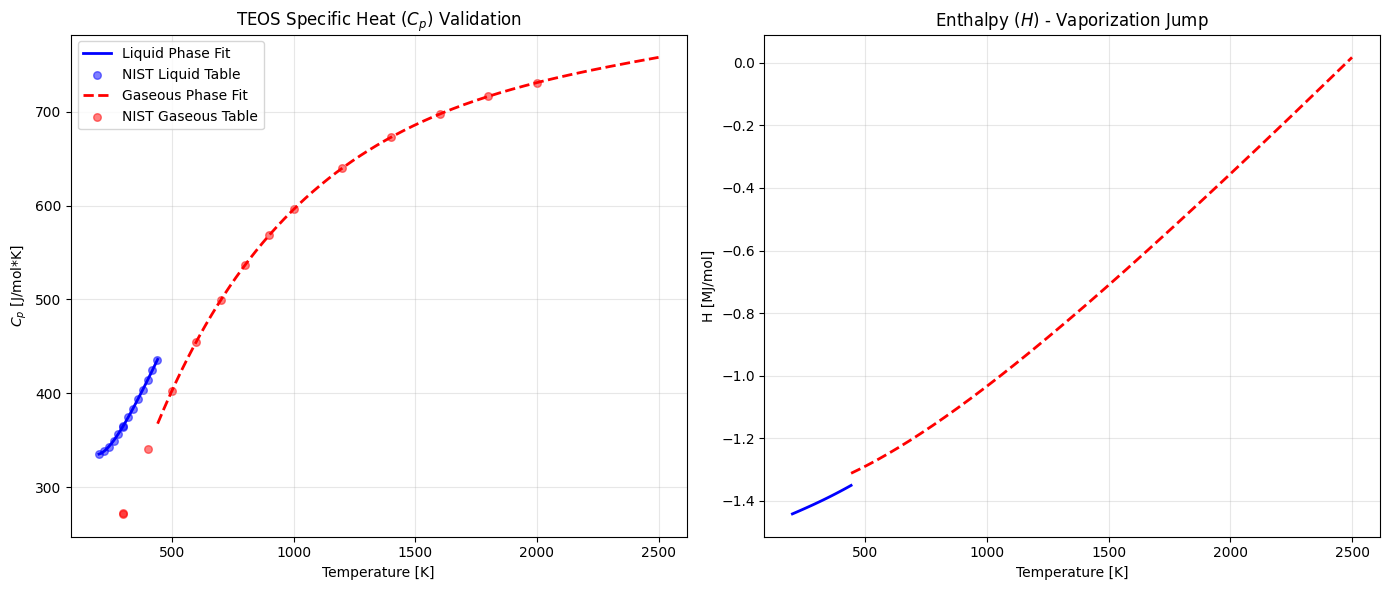


   DATA TO COPY INTO RPA (Polynomial Properties)

>>> RANGE 1: LIQUID
T1: 200.0 K  |  T2: 441.2 K
---------------------------------------------
a1         | 1.35783014e+06
a2         | -2.42888999e+04
a3         | 2.37557889e+02
a4         | -9.49825585e-01
a5         | 2.64227228e-03
a6         | -3.58186811e-06
a7         | 1.98761850e-09
b1 (a8)    | -7.22159618e+04
b2 (a9)    | -1.16975209e+03

>>> RANGE 2: GASEOUS
T1: 441.2 K  |  T2: 5000.0 K
---------------------------------------------
a1         | 1.89084072e+06
a2         | -1.59544104e+04
a3         | 4.96030203e+01
a4         | 5.94767676e-02
a5         | -2.95334915e-05
a6         | 6.74315005e-09
a7         | -5.59040863e-13
b1 (a8)    | -8.32709819e+04
b2 (a9)    | -2.64225391e+02



In [ ]:
def cp_calc(T, c):
    return R * (c[0]*T**-2 + c[1]*T**-1 + c[2] + c[3]*T + c[4]*T**2 + c[5]*T**3 + c[6]*T**4)

def h_calc(T, c):
    return R * T * (-c[0]*T**-2 + c[1]*np.log(T)/T + c[2] + (c[3]/2)*T + (c[4]/3)*T**2 + (c[5]/4)*T**3 + (c[6]/5)*T**4 + c[7]/T)

# Plotting ranges
T_liq_plot = np.linspace(200, 441.2, 100)
T_gas_plot = np.linspace(441.2, 2500, 500) 

# Table data for visual validation (Scatter)
T_liq_tab = np.array([200, 220, 240, 260, 280, 298.15, 300, 320, 340, 360, 380, 400, 420, 440])
Cp_R_liq_tab = np.array([40.31, 40.65, 41.24, 42.02, 42.92, 43.83, 43.93, 45.01, 46.15, 47.34, 48.55, 49.80, 51.07, 52.37])

T_gas_tab = np.array([298.15, 300, 400, 500, 600, 700, 800, 900, 1000, 1200, 1400, 1600, 1800, 2000])
Cp_R_gas_tab = np.array([271.402, 272.681, 341.040, 402.568, 454.859, 498.961, 536.407, 568.414, 595.884, 639.884, 672.703, 697.432, 716.308, 730.992]) / R

plt.figure(figsize=(14, 6))

# Subplot 1: Specific Heat (Regression Validation)
plt.subplot(1, 2, 1)
plt.plot(T_liq_plot, cp_calc(T_liq_plot, coeffs_liq), 'b', lw=2, label='Liquid Phase Fit')
plt.scatter(T_liq_tab, Cp_R_liq_tab * R, color='blue', s=30, alpha=0.5, label='NIST Liquid Table')

plt.plot(T_gas_plot, cp_calc(T_gas_plot, coeffs_gas), 'r--', lw=2, label='Gaseous Phase Fit')
plt.scatter(T_gas_tab, Cp_R_gas_tab * R, color='red', s=30, alpha=0.5, label='NIST Gaseous Table')

plt.title('TEOS Specific Heat ($C_p$) Validation')
plt.xlabel('Temperature [K]'); plt.ylabel('$C_p$ [J/mol*K]')
plt.legend(); plt.grid(alpha=0.3)

# Subplot 2: Enthalpy (Phase Transition)
plt.subplot(1, 2, 2)
plt.plot(T_liq_plot, h_calc(T_liq_plot, coeffs_liq)/1e6, 'b', lw=2)
plt.plot(T_gas_plot, h_calc(T_gas_plot, coeffs_gas)/1e6, 'r--', lw=2)
plt.title('Enthalpy ($H$) - Vaporization Jump')
plt.xlabel('Temperature [K]'); plt.ylabel('H [MJ/mol]')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- NASA 9 coefficient polynomials ---
print("\n" + "="*65)
print("   DATA TO COPY INTO RPA (Polynomial Properties)")
print("="*65)
names = ["a1","a2","a3","a4","a5","a6","a7","b1 (a8)","b2 (a9)"]

print(f"\n>>> RANGE 1: LIQUID")
print(f"T1: 200.0 K  |  T2: 441.2 K")
print("-" * 45)
for i in range(9):
    print(f"{names[i]:<10} | {coeffs_liq[i]:.8e}")

print(f"\n>>> RANGE 2: GASEOUS")
print(f"T1: 441.2 K  |  T2: 5000.0 K")
print("-" * 45)
for i in range(9):
    print(f"{names[i]:<10} | {coeffs_gas[i]:.8e}")
print("\n" + "="*65)